<a href="https://colab.research.google.com/github/excel432/Credit-Fraud-Detection-Corrected/blob/main/Predictive_Maintainance_For_Industrial_Equipment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np


In [10]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv

--2026-07-30 00:02:24--  https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘ai4i2020.csv.1’

ai4i2020.csv.1          [ <=>                ] 509.81K  --.-KB/s    in 0.05s   

2026-07-30 00:02:24 (10.4 MB/s) - ‘ai4i2020.csv.1’ saved [522048]



In [11]:
df = pd.read_csv('ai4i2020.csv')
print(df.shape)
df.head(10)

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [12]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


Machine failure
0    9661
1     339
Name: count, dtype: int64


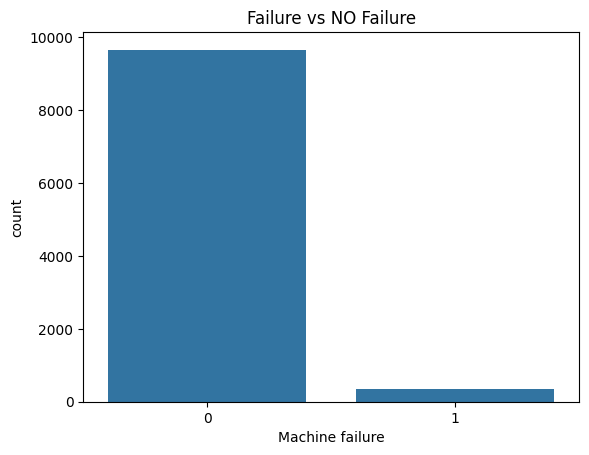

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df['Machine failure'].value_counts())

sns.countplot(x='Machine failure', data=df)
plt.title('Failure vs NO Failure')
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Type_enc'] = le.fit_transform(df['Type'])

df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power'] =df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['wear_torque_ratio'] = df['Tool wear [min]'] / (df['Torque [Nm]'] + 1e-3)

In [29]:
df[['Type_enc','temp_diff', 'power','wear_torque_ratio']].head()

,Type_enc,temp_diff,power,wear_torque_ratio
0,2,10.5,66382.8,0.000000
1,1,10.5,65190.4,0.064793
2,1,10.4,74001.2,0.101213
3,1,10.4,56603.5,0.177211
4,1,10.5,56320.0,0.224994


In [31]:
features = ['Type_enc', 'power', 'Air temperature [K]', 'Process temperature [K]', 'Torque [Nm]', 'Rotational speed [rpm]', 'temp_diff', 'Tool wear [min]', 'wear_torque_ratio']
x=df[features]
y=df['Machine failure']

print(x.shape, y.shape)

(10000, 9) (10000,)


In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape, x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(8000, 9) (2000, 9)
Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [42]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {'max_depth': [3,4,5], 'n_estimators':[100,200], 'learning_rate':[0.5, 0.1], 'scale_pos_weight': [1, 5, 10]}
base_model = XGBClassifier(eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_search.fit(x_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best F1 score (cross-validate):', grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1}
Best F1 score (cross-validate): 0.8129303527880675


In [44]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(x_test_scaled)
y_proba_final = best_model.predict_proba(x_test_scaled)[:, 1]

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

print (confusion_matrix(y_test, y_pred_final))
print("TEST F1:", f1_score(y_test, y_pred_final))
print("TEST ROC AUC:", roc_auc_score(y_test, y_proba_final))

train_pred_final = best_model.predict(x_train_scaled)
train_poba_final = best_model.predict_proba(x_train_scaled)[:, 1]
print("TRAIN F1:", f1_score(y_train, train_pred_final))
print("TRAIN ROC AUC:", roc_auc_score(y_train, train_poba_final))

[[1925    7]
 [  15   53]]
TEST F1: 0.828125
TEST ROC AUC: 0.9817927170868348
TRAIN F1: 0.9831144465290806
TRAIN ROC AUC: 0.9999737414892584


In [46]:
import joblib
joblib.dump(best_model, 'predictive_maintainance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Saved successfully!")

Saved successfully!


In [48]:
!ls -la * .pkl

ls: cannot access '.pkl': No such file or directory
-rw-r--r-- 1 root root 522048 Jul 30 00:01 ai4i2020.csv
-rw-r--r-- 1 root root 522048 Jul 30 00:02 ai4i2020.csv.1
-rw-r--r-- 1 root root 338243 Jul 30 01:43 predictive_maintainance_model.pkl
-rw-r--r-- 1 root root   1215 Jul 30 01:43 scaler.pkl

sample_data:
total 55512
drwxr-xr-x 1 root root     4096 Jun  4 13:32 .
drwxr-xr-x 1 root root     4096 Jul 30 01:43 ..
-rwxr-xr-x 1 root root     1697 Jan  1  2000 anscombe.json
-rw-r--r-- 1 root root   301141 Jun  4 13:32 california_housing_test.csv
-rw-r--r-- 1 root root  1706430 Jun  4 13:32 california_housing_train.csv
-rw-r--r-- 1 root root 18289443 Jun  4 13:32 mnist_test.csv
-rw-r--r-- 1 root root 36523880 Jun  4 13:32 mnist_train_small.csv
-rwxr-xr-x 1 root root      962 Jan  1  2000 README.md
